Training observations: 28
Test observations: 8
Positive class: diseased (1)

Accuracy  : 0.8750
Precision : 1.0000
Recall    : 0.8333
F1 Score  : 0.9091
ROC-AUC   : 0.9167

Confusion matrix (rows: actual; columns: predicted):
[[2 0]
 [1 5]]


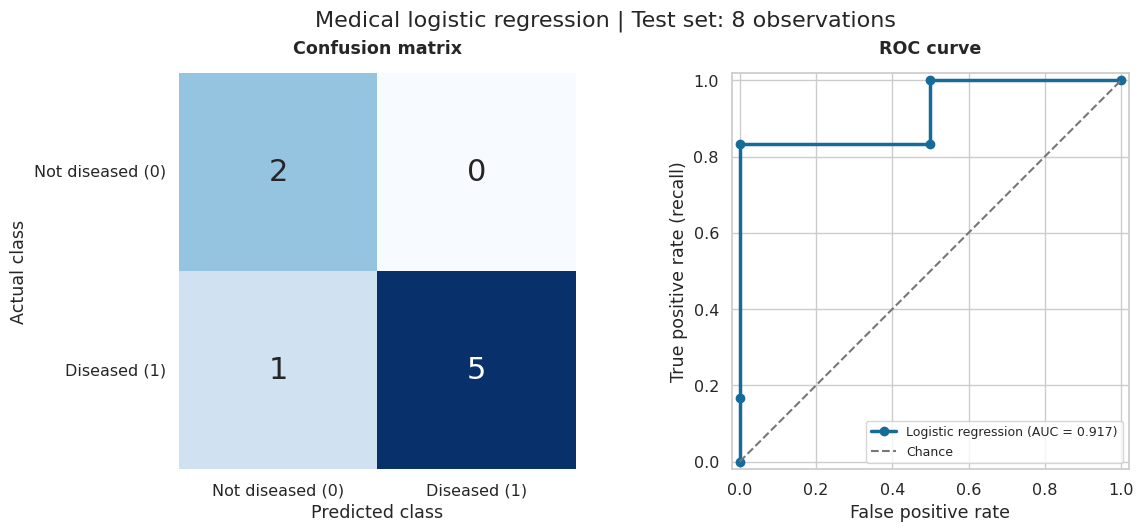


Result image saved to:
/content/output/medical_logistic_regression_results.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

# ============================================================
# LOAD DATASET
# ============================================================

df = pd.read_excel(
    "/content/Medical_Logistic_Regression_Dataset.xlsx",
    sheet_name=0
)

# ============================================================
# FEATURES AND TARGET
# ============================================================

X = df[["Age", "Gender", "Smoker status"]].copy()

X["Gender"] = X["Gender"].map({
    "Female": 0,
    "Male": 1
})

X["Smoker status"] = X["Smoker status"].map({
    "Non-smoker": 0,
    "Smoker": 1
})

y = df["Disease"].map({
    "not diseased": 0,
    "diseased": 1
})

# Check for missing/unrecognized values
if X.isna().any().any() or y.isna().any():
    raise ValueError(
        "Missing values or unrecognized category labels in the dataset."
    )

# ============================================================
# 80/20 TRAIN-TEST SPLIT
# ============================================================

# Use the requested ordinary random 80/20 split
# without stratification.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=5
)

# ============================================================
# LOGISTIC REGRESSION MODEL
# ============================================================

# StandardScaler is fitted only on training data.
model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        random_state=5,
        max_iter=1000
    )),
])

# Train model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Probability of diseased class
y_probability = model.predict_proba(X_test)[:, 1]

# ============================================================
# EVALUATION METRICS
# ============================================================

auc = roc_auc_score(
    y_test,
    y_probability
)

metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(
        y_test,
        y_pred,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        y_pred,
        zero_division=0
    ),
    "F1 Score": f1_score(
        y_test,
        y_pred,
        zero_division=0
    ),
    "ROC-AUC": auc,
}

print(f"Training observations: {len(X_train)}")
print(f"Test observations: {len(X_test)}")
print("Positive class: diseased (1)")
print()

for name, value in metrics.items():
    print(f"{name:10s}: {value:.4f}")

# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=[0, 1]
)

print("\nConfusion matrix (rows: actual; columns: predicted):")
print(cm)

# ============================================================
# PLOTS
# ============================================================

sns.set_theme(
    style="whitegrid",
    font_scale=1.05
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5.2),
    constrained_layout=True
)

labels = [
    "Not diseased (0)",
    "Diseased (1)"
]

# ------------------------------------------------------------
# CONFUSION MATRIX HEATMAP
# ------------------------------------------------------------

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=labels,
    yticklabels=labels,
    square=True,
    annot_kws={"size": 22},
    ax=axes[0],
)

axes[0].set_title(
    "Confusion matrix",
    fontweight="bold",
    pad=14
)

axes[0].set_xlabel("Predicted class")
axes[0].set_ylabel("Actual class")
axes[0].tick_params(
    axis="y",
    rotation=0
)

# ------------------------------------------------------------
# ROC CURVE
# ------------------------------------------------------------

fpr, tpr, _ = roc_curve(
    y_test,
    y_probability
)

axes[1].plot(
    fpr,
    tpr,
    marker="o",
    linewidth=2.5,
    color="#166b99",
    label=f"Logistic regression (AUC = {auc:.3f})"
)

axes[1].plot(
    [0, 1],
    [0, 1],
    "--",
    color="#777777",
    label="Chance"
)

axes[1].set(
    xlim=(-0.02, 1.02),
    ylim=(-0.02, 1.02),
    xlabel="False positive rate",
    ylabel="True positive rate (recall)"
)

axes[1].set_title(
    "ROC curve",
    fontweight="bold",
    pad=14
)

axes[1].set_aspect(
    "equal",
    adjustable="box"
)

axes[1].legend(
    loc="lower right",
    fontsize=9
)

# Overall title
fig.suptitle(
    f"Medical logistic regression | Test set: {len(X_test)} observations",
    fontsize=16
)

# ============================================================
# SAVE RESULT
# ============================================================

output_dir = Path("/content/output")
output_dir.mkdir(
    parents=True,
    exist_ok=True
)

fig.savefig(
    output_dir / "medical_logistic_regression_results.png",
    dpi=180,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

plt.close(fig)

print("\nResult image saved to:")
print("/content/output/medical_logistic_regression_results.png")